In [68]:
import sys
sys.path.append("..")

from src.Preprocessing import get_preprocessed_data

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [69]:
X_train, X_test, y_train, y_test = get_preprocessed_data(split=True)

In [70]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(12099,)

In [71]:
X_train.head()

,Latitude,Longitude,PostalCode,StreetNumberNumeric,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,...,Flooring_Concrete,Flooring_Brick,Flooring_Vinyl,Flooring_Tile,Flooring_Carpet,Flooring_Wood,Levels_MultiSplit,Levels_Two,Levels_One,Levels_ThreeOrMore
58790,34.212819,-119.167665,93030,1171.0,True,2.0,4.0,True,2.0,2105.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
46020,33.726214,-117.830330,92780,14880.0,True,3.0,3.0,True,2.0,1312.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
31352,33.224203,-117.305827,92057,4265.0,True,2.0,2.0,False,1.0,1056.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20664,33.686585,-117.627864,92679,18972.0,True,2.0,3.0,True,2.0,1210.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
10115,34.258819,-118.401925,91331,10348.0,True,3.0,4.0,False,2.0,1490.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [72]:
X_train.columns

Index(['Latitude', 'Longitude', 'PostalCode', 'StreetNumberNumeric',
       'AttachedGarageYN', 'BathroomsTotalInteger', 'BedroomsTotal',
       'FireplaceYN', 'GarageSpaces', 'LivingArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'ParkingTotal', 'PoolPrivateYN', 'Stories',
       'ViewYN', 'YearBuilt', 'LotSizeAcres', 'LotSizeArea',
       'LotSizeSquareFeet', 'AssociationFee', 'ClosePrice', 'DaysOnMarket',
       'sin_closed_date', 'Flooring_SeeRemarks', 'Flooring_Stone',
       'Flooring_Bamboo', 'Flooring_Laminate', 'Flooring_Concrete',
       'Flooring_Brick', 'Flooring_Vinyl', 'Flooring_Tile', 'Flooring_Carpet',
       'Flooring_Wood', 'Levels_MultiSplit', 'Levels_Two', 'Levels_One',
       'Levels_ThreeOrMore'],
      dtype='str')

# Ridge Regression

In [73]:
"ClosePrice" in X_train.columns

True

I removed ClosePrice from feature set since it would cause target leakage and the model would directly learn the answer.

In [74]:
X_train = X_train.drop(columns=["ClosePrice"], errors="ignore")
X_test = X_test.drop(columns=["ClosePrice"], errors="ignore")

In [75]:
X_train_enc = pd.get_dummies(X_train)
X_test_enc = pd.get_dummies(X_test)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

X_train_enc = X_train_enc.astype(float).fillna(0)
X_test_enc = X_test_enc.astype(float).fillna(0)

In [76]:
model = Ridge()
model.fit(X_train_enc, y_train)

y_pred = model.predict(X_test_enc)

/Users/jenny/Desktop/IDX Exchange Intership/California-House-Price-Prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.253185866434715e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


$R^2$

In [77]:
model.score(X_test_enc, y_test)

r2_ridge = r2_score(y_test, y_pred)
print("Ridge R2:", r2_ridge)

Ridge R2: 0.5710084066845312


MdAPE

In [78]:
y_test_price = np.exp(y_test)
y_pred_price = np.exp(y_pred)

mdape_ridge = np.median(np.abs((y_test_price - y_pred_price) / y_test_price)) * 100
print("Ridge MdAPE (%):", mdape_ridge)

Ridge MdAPE (%): 20.586085096880176


# Linear Regression

In [79]:
lm = LinearRegression()

lm.fit(X_train_enc, y_train)

y_pred_lm = lm.predict(X_test_enc)

$R^2$

In [80]:
r2_lm = r2_score(y_test, y_pred_lm)
print("Linear Model R2:", r2_lm)

Linear Model R2: 0.5710111770288866


MdAPE

In [81]:
y_test_price = np.exp(y_test)
y_pred_price_lm = np.exp(y_pred_lm)

mdape_lm = np.median(np.abs((y_test_price - y_pred_price_lm) / y_test_price)) * 100
print("Linear Model MdAPE (%):", mdape_lm)

Linear Model MdAPE (%): 20.58294283987261


QQ-Plot

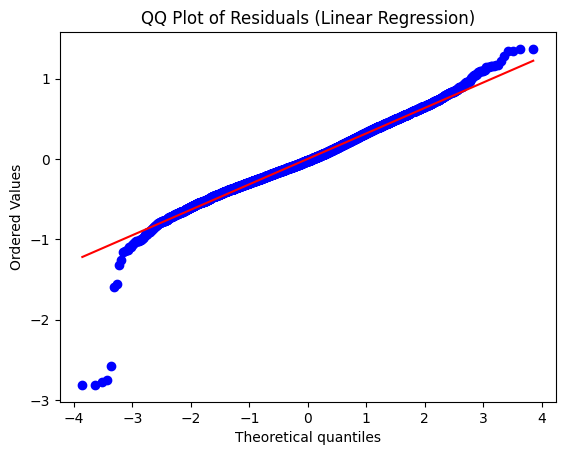

In [82]:
residuals = y_test - y_pred_lm

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals (Linear Regression)")
plt.show()

# Random Forest (Based on Eddie's Idea)

Since tree models in sklearn require numeric inputs, categorical variables were converted into integer codes and boolean variables were converted to 0/1. Missing values were filled with -1 as a placeholder.

In [83]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

X_train_rf = X_train_rf.drop(columns=["ClosePrice"], errors="ignore")
X_test_rf = X_test_rf.drop(columns=["ClosePrice"], errors="ignore")

cat_cols = X_train_rf.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    train_col = X_train_rf[col].astype("string")
    test_col = X_test_rf[col].astype("string")

    all_vals = pd.Index(train_col.dropna().unique()).union(
        pd.Index(test_col.dropna().unique())
    )

    mapping = {val: i for i, val in enumerate(all_vals)}

    X_train_rf[col] = train_col.map(mapping).fillna(-1).astype(int)
    X_test_rf[col] = test_col.map(mapping).fillna(-1).astype(int)

bool_cols = X_train_rf.select_dtypes(include=["bool", "boolean"]).columns

for col in bool_cols:
    X_train_rf[col] = X_train_rf[col].fillna(False).astype(int)
    X_test_rf[col] = X_test_rf[col].fillna(False).astype(int)

num_cols = X_train_rf.columns.difference(cat_cols.union(bool_cols))

X_train_rf[num_cols] = X_train_rf[num_cols].apply(pd.to_numeric, errors="coerce").fillna(-1)
X_test_rf[num_cols] = X_test_rf[num_cols].apply(pd.to_numeric, errors="coerce").fillna(-1)

In [84]:
print(X_train_rf.isna().sum().sum())
print(X_test_rf.isna().sum().sum())
print(X_train_rf.dtypes.value_counts())

0
0
float64    30
int64       7
Name: count, dtype: int64


In [85]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
)

rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

$R^2$

In [86]:
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R2:", r2_rf)

Random Forest R2: 0.8074682730918104


MdAPE

In [87]:
y_test_price = np.exp(y_test)
y_pred_price_rf = np.exp(y_pred_rf)

mdape_rf = np.median(np.abs((y_test_price - y_pred_price_rf) / y_test_price)) * 100
print("Random Forest MdAPE (%):", mdape_rf)

Random Forest MdAPE (%): 11.388648643045993


# LASSO Regression

In [88]:
X_train_enc.shape

(48407, 37)

Since the feature space becomes very high-dimensional after one-hot encoding, LASSO may be more suitable than Ridge.

In [89]:
lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.0001)
)

lasso.fit(X_train_enc, y_train)

y_pred_lasso = lasso.predict(X_test_enc)

$R^2$

In [90]:
r2_lasso = r2_score(y_test, y_pred_lasso)
print("Lasso R2:", r2_lasso)

Lasso R2: 0.5710216377650541


MdAPE

In [91]:
y_pred_price_lasso = np.exp(y_pred_lasso)

mdape_lasso = np.median(
    np.abs((y_test_price - y_pred_price_lasso) / y_test_price)
) * 100

print("Lasso MdAPE (%):", mdape_lasso)

Lasso MdAPE (%): 20.62012644575142


# Results Comparison

In [92]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "LASSO", "Random Forest"],
    "R2": [r2_lm, r2_ridge, r2_lasso, r2_rf],
    "MdAPE (%)": [mdape_lm, mdape_ridge, mdape_lasso, mdape_rf]
})

results

,Model,R2,MdAPE (%)
0,Linear Regression,0.571011,20.582943
1,Ridge,0.571008,20.586085
2,LASSO,0.571022,20.620126
3,Random Forest,0.807468,11.388649
